<a href="https://colab.research.google.com/github/Kwasi-Scientist/CarPricePrediction/blob/main/CarPricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
!pip install numpy pandas matplotlib seaborn

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

Random Seed

In [45]:
random.seed(123)

In [46]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/MLBookCamp/CarPrice/data.csv")

In [48]:
len(df)

11914

In [49]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


column names and some feature values have a mix of "-" and spaces

want to make sure everything is in the same capitalization

In [50]:
df.columns = df.columns.str.lower().str.replace(" ","_") #replace space with underscores

string_columns = list(df.dtypes[df.dtypes== "object"].index) #select cols with string values

for col in string_columns:
  df[col] = df[col].str.lower().str.replace(" ","_")

In [51]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


Examine y, the MSRP or price

Check the distributsion

Check for missing values

<Axes: xlabel='msrp', ylabel='Count'>

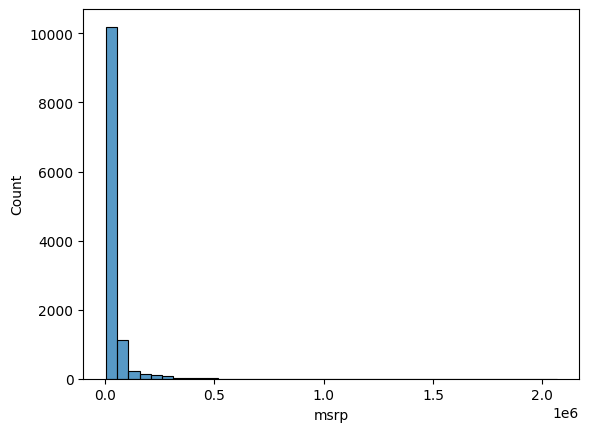

In [52]:
sns.histplot(df.msrp, bins=40)


#long tail on this plot indicating few cars with high MSRP

<Axes: xlabel='msrp', ylabel='Count'>

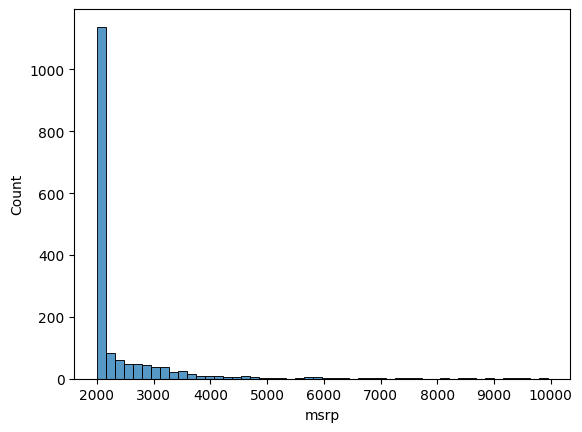

In [53]:
#zoom in to msrp values < 10k

sns.histplot(df[df.msrp<10000].msrp, bins=50)


In [54]:
#log transform the MSRP

log_price = np.log1p(df.msrp)

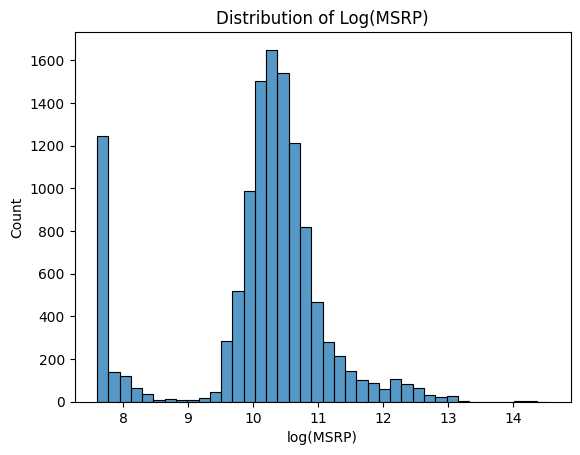

In [55]:
#check distribution of log transformed MSRP
sns.histplot(log_price, bins = 40)
plt.xlabel("log(MSRP)")
plt.title("Distribution of Log(MSRP)")
plt.show()

Remember linear regression models work well on normally distributed data

In [56]:
#check for missing values

df.isna().sum()

,0
make,0
model,0
year,0
engine_fuel_type,3
engine_hp,69
engine_cylinders,30
transmission_type,0
driven_wheels,0
number_of_doors,6
market_category,3742


In [57]:
#split the data set into train (60%), validation (20%), and test (20%)

#get the total number of rows

n = len(df)

#take 20% of data for validation
n_val = int(0.2*n)

#take 20% of data for test
n_test = int(0.2*n)

#subtract n_val and n_test from n to get the remaining 60% for training data
n_train = n - (n_val + n_test)

#random seed done at the top of notebook

idx = np.arange(n)
#create randomly shuffled np array
np.random.shuffle(idx)

#random shuffle df
df_shuffled = df.iloc[idx]

#create train, val, and test dfs from df_shuffle
df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()


In [58]:
#log transform all MSPR values of dfs

y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)


In [59]:
#delete the y values in the dfs so we don't accidentally use it later

del df_train["msrp"]
del df_val["msrp"]
del df_test["msrp"]

Define Model

In [60]:
#now code the linear regression function


#code dot product
def dot(xi, w):
  n = len(w)
  result = 0.0
  for j in range(n):
    result - result +xi[j] * w[j]
  return result



def linear_regression(xi):
  xi =[1] +xi
  return dot(xi,w)


Train Model

In [61]:
#write training function

def train_linear_regression(X, y):
  #add dummy col
  ones = np.ones(X.shape[0])
  X = np.column_stack([ones, X])  #adds dummy col as the first col of X

  #normal equation forumla
  XTX = X.T.dot(X)
  XTX_inv = np.linalg.inv(XTX)
  w = XTX_inv.dot(X.T).dot(y)

  return w[0], w[1:] #splite the weights vector into the bias and the rest of the weights

Predict

In [62]:
#Select features

base = ["engine_hp", "engine_cylinders", "highway_mpg", "city_mpg", "popularity"]

df_num = df_train[base]

In [63]:
#if features have missing values fill with 0s
#features with 0 will have no contribution to the final prediction

df_num =df_num.fillna(0)

In [64]:
#convert df to np array

X_train = df_num.values

In [65]:
#train

w_0, w = train_linear_regression(X_train,y_train)

In [66]:
#predict

y_pred = w_0 + X_train.dot(w)

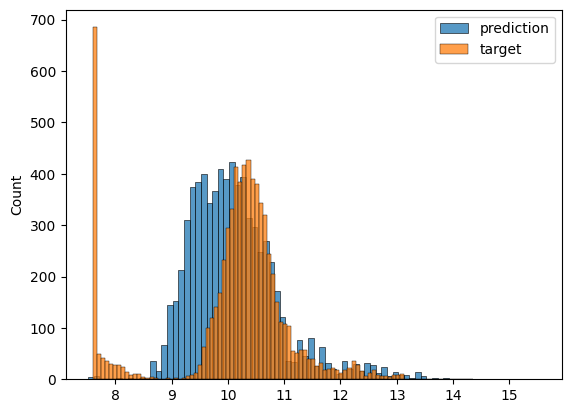

In [67]:
#plot prediction values on historgram and compare with actual prices

sns.histplot(y_pred, label="prediction")
sns.histplot(y_train, label = "target")
plt.legend()
plt.show()


#note the discrepancy in between the prediction and target distributions
#this is due to the simplicity of the model

Evaluate Model Quality

In [68]:
#use RMSE to evaluate model quality

def rmse(y, y_pred):
  error = y_pred -y
  mse = (error **2).mean()
  return np.sqrt(mse)

In [69]:
rmse(y_train, y_pred)

np.float64(0.7528435610684077)

In [70]:
#when comparing RMSE, the model with the lowest RMSE is the better performing model

Validating the model

In [71]:
#create the validation matrix
df_num = df_val[base]
df_num = df_num.fillna(0)
X_val = df_num.values

In [72]:
#apply the model to X_val to get predictions
y_pred = w_0+ +X_val.dot(w)

In [73]:
#use ypred and compare it to the acrual prices from y_val using the rmse function
rmse(y_val, y_pred)


#THis is the nyumber we should use for comparing models

np.float64(0.745525074721651)

In [74]:
#write the function prepare_X which converts a dataframe into into a matrix

def prepare_X(df):
  """
  prepare a model feature martrix (X) from a pandas DataFrame.

  Parameters
  ----------
  df : pandas.DataFrame
      Input DataDrame containing all avaialable columns, including the feature columns.

  External Variable
  -----------------
  base: list[str]
      List of column names to select from `df` as model features.
      NOTE: `base` must exist in the outer scope and all columns in `base` must be present in `df`.
  Returns
  -------
  X: numpy.ndarray
      Feature matrix with shape (n_samples, n_features), derived from `df[base]`.
  """
  # Step 1: Select onlt the feature columns defined by `base`
  df_num = df[base]

  #step 2: fill missing values in the selected feature columns with zero
  df_num = df_num.fillna(0)

  #step 3: convert the DataFrame of features into a NumPy array
  X = df_num.values

  #Step 4: return the feature matrix
  return X




In [75]:
#from re import X
# the whole simplified training and evaluation pipline becomes the following:

X_train = prepare_X(df_train)
x_0, w = train_linear_regression(X_train,y_train)

X_val = prepare_X(df_val)
y_pred = w_0 +X_val.dot(w)
print('validation:', rmse(y_val, y_pred))

validation: 0.745525074721651


Simple Feature Engineering

In [76]:
#Add an `age` feature to the model denoting the age of the car
#we anticipate the newer the car the more expensive the car will be
# subtract the year the car was made by 2017 to find the car `age`

df_train['age'] = 2017 - df_train.year

In [77]:
#add `age` to prepare_X

#write the function prepare_X which converts a dataframe into into a matrix

def prepare_X(df):
  """
  Construct a model-ready feature matrix (X) from a pandas DataFrame.

  This function:
  1) Creates a defensive copy of the input DataFrame.
  2) Derives an `age` feature from the `year` column (using 2017 as the reference year).
  3) Selects the feature columns specified by `base` (see External Variables).
  4) Fills missing values with 0.
  5) Returns the resulting feature matrix as a NumPy array.

  Parameters
  ----------
  df : pandas.DataFrame
      Input DataFrame containing the raw input variables required for feature construction.
      Expected to include the columns referenced by `base`, and a `year` column (used to compute `age`).

  External Variables
  ------------------
  base : list[str]
      List of column names to be used as model features.
      NOTE: `base` must exist in the outer scope and all columns in `base` must be present in `df`.

  Returns
  -------
  X : numpy.ndarray
      Feature matrix of shape (n_samples, n_features) derived from the selected columns.
      Missing values are imputed as 0 prior to conversion.

  Notes
  -----
  - The `age` feature is computed as: age = 2017 - df['year'].
    If your dataset uses a different reference year, update this constant accordingly.
  - If `year` contains missing or non-numeric values, `age` may be incorrect or raise errors.
  """

  # Step 1: Copy df to avoid mutating the caller's DataFrame
  df = df.copy()

  # Step 2: Create a copy of the base list (feature names)
  features = base.copy()

  # Step 3: Compute age feature from the `year` column
  df['age'] = 2017 - df.year

  # Step 4: Append `age` to the list of features used for modeling
  features.append('age')

  # Step 5: Select only the feature columns used for the model
  df_num = df[features]

  # Step 6: Fill missing values in selected feature columns with zero
  df_num = df_num.fillna(0)

  # Step 7: Convert the feature DataFrame into a NumPy array
  X = df_num.values

  # Step 8: Return the feature matrix
  return X





In [78]:
X_train = prepare_X(df_train)
w_0, w= train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation:', rmse(y_val, y_pred))

validation: 0.5104147676454279


In [79]:
#age was indeed helpful in making predictions

In [80]:
#now look at the distribution

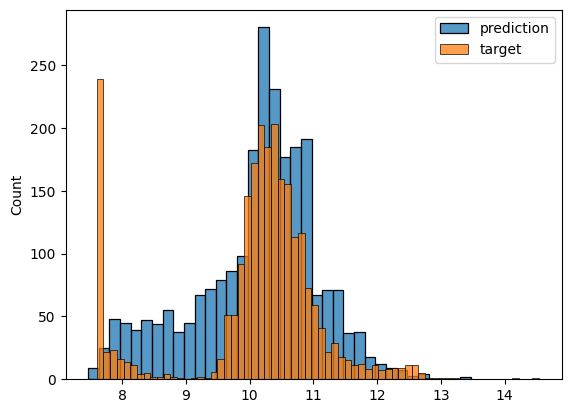

In [81]:
sns.histplot(y_pred, label='prediction')
sns.histplot(y_val, label='target')
plt.legend()


Handling Categorical Values

In [82]:
#add one hot encoding of number of doors to prepare_X

#write the function prepare_X which converts a dataframe into into a matrix

def prepare_X(df):
  """
  Construct a model-ready feature matrix (X) from a pandas DataFrame.

  This function:
  1) Creates a defensive copy of the input DataFrame.
  2) Derives an `age` feature from the `year` column (using 2017 as the reference year).
  3) Selects the feature columns specified by `base` (see External Variables).
  4) Fills missing values with 0.
  5) Returns the resulting feature matrix as a NumPy array.

  Parameters
  ----------
  df : pandas.DataFrame
      Input DataFrame containing the raw input variables required for feature construction.
      Expected to include the columns referenced by `base`, and a `year` column (used to compute `age`).

  External Variables
  ------------------
  base : list[str]
      List of column names to be used as model features.
      NOTE: `base` must exist in the outer scope and all columns in `base` must be present in `df`.

  Returns
  -------
  X : numpy.ndarray
      Feature matrix of shape (n_samples, n_features) derived from the selected columns.
      Missing values are imputed as 0 prior to conversion.

  Notes
  -----
  - The `age` feature is computed as: age = 2017 - df['year'].
    If your dataset uses a different reference year, update this constant accordingly.
  - If `year` contains missing or non-numeric values, `age` may be incorrect or raise errors.
  """

  # Step 1: Copy df to avoid mutating the caller's DataFrame
  df = df.copy()

  # Step 2: Create a copy of the base list (feature names)
  features = base.copy()

  # Step 3: Compute age feature from the `year` column
  df['age'] = 2017 - df.year

  # Step 4: Append `age` to the list of features used for modeling
  features.append('age')

  # Step 5: One hot encode number of doors
  for v in [2,3,4]: #iter over the numbner of door values
    feature = 'num_doors_%s' % v  #give a feature a meaningfule name
    values = (df['numbner_of_doors'] == v).astype(int) # creates the one hot encoding feature
    df[feature] = values #adds the feature back to the esdf using the name from earlier
    features.append(feature)

  # Step 5: Select only the feature columns used for the model
  df_num = df[features]

  # Step 6: Fill missing values in selected feature columns with zero
  df_num = df_num.fillna(0)

  # Step 7: Convert the feature DataFrame into a NumPy array
  X = df_num.values

  # Step 8: Return the feature matrix
  return X





In [83]:
#investigate `make` of the cars

df['make'].value_counts().head(5)

,count
make,
chevrolet,1123
ford,881
volkswagen,809
toyota,746
dodge,626


In [84]:
#add one hot encoding of number of doors to prepare_X

#write the function prepare_X which converts a dataframe into into a matrix

def prepare_X(df):
  """
  Construct a model-ready feature matrix (X) from a pandas DataFrame.

  This function:
  1) Creates a defensive copy of the input DataFrame.
  2) Derives an `age` feature from the `year` column (using 2017 as the reference year).
  3) Selects the feature columns specified by `base` (see External Variables).
  4) Fills missing values with 0.
  5) Returns the resulting feature matrix as a NumPy array.

  Parameters
  ----------
  df : pandas.DataFrame
      Input DataFrame containing the raw input variables required for feature construction.
      Expected to include the columns referenced by `base`, and a `year` column (used to compute `age`).

  External Variables
  ------------------
  base : list[str]
      List of column names to be used as model features.
      NOTE: `base` must exist in the outer scope and all columns in `base` must be present in `df`.

  Returns
  -------
  X : numpy.ndarray
      Feature matrix of shape (n_samples, n_features) derived from the selected columns.
      Missing values are imputed as 0 prior to conversion.

  Notes
  -----
  - The `age` feature is computed as: age = 2017 - df['year'].
    If your dataset uses a different reference year, update this constant accordingly.
  - If `year` contains missing or non-numeric values, `age` may be incorrect or raise errors.
  """

  # Step 1: Copy df to avoid mutating the caller's DataFrame
  df = df.copy()

  # Step 2: Create a copy of the base list (feature names)
  features = base.copy()

  # Step 3: Compute age feature from the `year` column
  df['age'] = 2017 - df.year

  # Step 4: Append `age` to the list of features used for modeling
  features.append('age')

  # Step 5: One hot encode number of doors
  for v in [2,3,4]: #iter over the numbner of door values
    feature = 'num_doors_%s' % v  #give a feature a meaningfule name
    df[feature] = (df['number_of_doors'] == v).astype(int) # creates the one hot encoding feature
    features.append(feature) #adds the feature back to the esdf using the name from earlier

  # Step 6: One hot encode `make`
  for v in ['chevrolet', 'ford','volkswagen', 'toyota', 'dodge']: #itter through all `make`
    feature = 'is_make_%s' % v  #give each a unique name
    df[feature] =(df['make'] == v).astype(int) #create the one hot encode
    features.append(feature)  #add feature to feature list

  # Step 7: Select only the feature columns used for the model
  df_num = df[features]

  # Step 8: Fill missing values in selected feature columns with zero
  df_num = df_num.fillna(0)

  # Step 9: Convert the feature DataFrame into a NumPy array
  X = df_num.values

  # Step 10: Return the feature matrix
  return X





In [85]:
X_train = prepare_X(df_train)
w_0, w= train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation:', rmse(y_val, y_pred))

validation: 0.49793252876277705


In [86]:
 #Now add one hot encoding for `engine_fuel_type`, `transimssion_type`, `driven_wheels`, `market_category`, `vehicle_size`, and `vehicle_style`

def prepare_X(df):
  """
  Build a model-ready feature matrix (X) from a pandas DataFrame by engineering numeric
  and one-hot-encoded categorical features.

  Specifically, the function:
  1) Creates a defensive copy of `df` to avoid mutating the caller’s data.
  2) Adds an `age` feature computed from `year` using a fixed reference year (2017).
  3) One-hot encodes several categorical columns (e.g., number_of_doors, make, fuel type,
     transmission type, driven wheels, market category, vehicle size, vehicle style).
  4) Selects the final feature set and imputes missing values with 0.
  5) Returns the resulting NumPy feature matrix.

  Parameters
  ----------
  df : pandas.DataFrame
      Input DataFrame containing the raw columns required for feature engineering.
      Must include:
        - All columns listed in the external `base` feature list
        - 'year'
        - 'number_of_doors'
        - 'make'
        - 'engine_fuel_type'
        - 'transmission_type'
        - 'driven_wheels'
        - 'market_category'
        - 'vehicle_size'
        - 'vehicle_style'

  External Variables
  ------------------
  base : list[str]
      Baseline feature column names to start from.
      NOTE: `base` must exist in the outer scope and all columns in `base` must be present in `df`.

  Returns
  -------
  X : numpy.ndarray
      Feature matrix of shape (n_samples, n_features) after feature engineering and imputation.
      Missing values are imputed as 0 prior to conversion.

  Notes
  -----
  - The `age` feature is computed as: age = 2017 - df['year'].
    If you want the model to remain valid across years, consider replacing 2017 with a
    parameter or using the current year consistently during training and inference.
  - One-hot encoding is performed using hard-coded category values. Any category values
    not listed in the loops will be encoded as all-zeros for that feature family.
  """

  # Step 1: Copy df to avoid mutating the caller's DataFrame
  df = df.copy()

  # Step 2: Create a copy of the base list (feature names)
  features = base.copy()

  # Step 3: Compute age feature from the `year` column
  df['age'] = 2017 - df.year

  # Step 4: Append `age` to the list of features used for modeling
  features.append('age')

  # Step 5: One hot encode number of doors
  for v in [2,3,4]: #iter over the numbner of door values
    feature = 'num_doors_%s' % v  #give a feature a meaningfule name
    df[feature] = (df['number_of_doors'] == v).astype(int) # creates the one hot encoding feature
    features.append(feature) #adds the feature back to the esdf using the name from earlier

  # Step 6: One hot encode `make`
  for v in ['chevrolet', 'ford','volkswagen', 'toyota', 'dodge']: #itter through all `make`
    feature = 'is_make_%s' % v  #give each a unique name
    df[feature] =(df['make'] == v).astype(int) #create the one hot encode
    features.append(feature)  #add feature to feature list

  # Step 7: One hot encode `fuel_type`
  for v in ['regular_unleaded', 'premium_unleaded_(required)',
              'premium_unleaded_(recommended)', 'flex-fuel_(unleaded/e85)']:
    feature = 'is_type_%s' % v
    df[feature] = (df['engine_fuel_type'] == v).astype(int)
    features.append(feature)
  # Step8: one hot encode `transmission_type`
  for v in ['automatic', 'manual', 'automated_manual']:
    feature = 'is_transmission_%s' % v
    df[feature] = (df['transmission_type'] == v).astype(int)
    features.append(feature)

  #Step 9: one hot encode `driven_wheels
  for v in ['front_wheel_drive', 'rear_wheel_drive', 'all_wheel_drive', 'four_wheel_drive']:
    feature = 'is_driven_wheens_%s' % v
    df[feature] = (df['driven_wheels'] == v).astype(int)
    features.append(feature)

  # Step 10: one hot encode `maket category`
  for v in ['crossover', 'flex_fuel', 'luxury', 'luxury,performance', 'hatchback']:
    feature = 'is_mc_%s' % v
    df[feature] = (df['market_category'] == v).astype(int)
    features.append(feature)

  # Step 11: one hot encode `vehicle_size`
  for v in ['compact', 'midsize', 'large']:
    feature = 'is_size_%s' % v
    df[feature] = (df['vehicle_size'] == v).astype(int)
    features.append(feature)

  # Step 12: one hot encode `vehicle style`
  for v in ['sedan', '4dr_suv', 'coupe', 'convertible', '4dr_hatchback']:
    feature = 'is_style_%s' % v
    df[feature] = (df['vehicle_style'] == v).astype(int)
    features.append(feature)


  # Step 13: Select only the feature columns used for the model
  df_num = df[features]

  # Step 14: Fill missing values in selected feature columns with zero
  df_num = df_num.fillna(0)

  # Step 15: Convert the feature DataFrame into a NumPy array
  X = df_num.values

  # Step 16: Return the feature matrix
  return X

In [87]:
X_train = prepare_X(df_train)
w_0, w= train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation:', rmse(y_val, y_pred))

validation: 126.91043771094459


In [88]:
#notice the huge jump in error indicating that the addition of the features are not helping prediction

Regularization

In [91]:
#regularization ensure the matrix is invertable and controls the weights so they behave correctly and don't grow too large

#make a new train linear regression function that includes regularization

def train_linear_regression_reg(X, y, r=0.0):
  """
  Train a regularized linear regression model using the closed-form (normal equation).

  The model is:
      y_hat = w0 + X @ w

  where:
    - w0 is the intercept (bias term)
    - w is the vector of feature weights

  Parameters
  ----------
  X : numpy.ndarray
      Feature matrix of shape (n_samples, n_features). Each row is one sample.
  y : numpy.ndarray
      Target vector of shape (n_samples,) containing the continuous response values.
  r : float, optional (default=0.0)
      Regularization strength (intended as L2 / ridge). Larger values should shrink weights more.

  Returns
  -------
  w0 : float
      Intercept term (bias).
  w : numpy.ndarray
      Weight vector of shape (n_features,).

  Notes
  -----
  - This implementation adds a column of ones to X to learn an intercept.
  - As currently written, the regularization matrix `reg` is computed but NOT applied.
    For true ridge regression, you would invert (X^T X + rI) instead of (X^T X).
  - Using np.linalg.inv can be numerically unstable for ill-conditioned matrices;
    np.linalg.solve is typically preferred in production code.
  """

  # Step 1: Create an intercept column (vector of ones) so the model can learn w0
  ones = np.ones(X.shape[0])

  # Step 2: Add the intercept column to the feature matrix
  X = np.column_stack([ones, X])

  # Step 3: Compute X^T X (a square matrix used in the normal equation)
  XTX = X.T.dot(X)

  # Step 4: Create the L2 regularization matrix (ridge penalty)
  # NOTE: This is currently unused in the inversion below.
  reg = r * np.eye(XTX.shape[0])

  # Step 5: add regularization
  XTX = XTX + reg

  # Step 6: Invert X^T X (normal equation component)
  XTX_inv = np.linalg.inv(XTX)

  # Step 7: Compute weights via normal equation: w = (X^T X)^(-1) X^T y
  w = XTX_inv.dot(X.T).dot(y)

  # Step 8: Return intercept (w0) and coefficients (w)
  return w[0], w[1:]


In [94]:
#experiment with different values of r
for r in [0, 0.001, 0.01, 0.1, 1, 10]:
  w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
  print('%5s, %.2f, %.2f, %.2f' % (r, w_0, w[13], w[21]))

    0, 25449867995247192.00, -8.24, -25449867995236564.00
0.001, 7.23, -0.08, 1.84
 0.01, 7.22, -0.08, 1.83
  0.1, 7.05, -0.08, 1.79
    1, 6.08, -0.07, 1.54
   10, 4.33, -0.06, 1.08


In [95]:
#check RMSE with regularization r = 0.001

X_train = prepare_X(df_train)
w_0, w = train_linear_regression_reg(X_train, y_train, r=0.001)

x_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation:', rmse(y_val, y_pred))

validation: 0.45121162930178516


In [96]:
#the result has improved

In [99]:
#trying addtional r values

X_train = prepare_X(df_train)
X_val = prepare_X(df_val)

for r in [0.000001, 0.0001, 0.001, 0.01, 0.1, 1, 5, 10]:
  w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
  y_pred = w_0 + X_val.dot(w)
  print('%6s' %r, rmse(y_val, y_pred))

 1e-06 0.4512101609115341
0.0001 0.45121031249007515
 0.001 0.45121162930178516
  0.01 0.45122483746031633
   0.1 0.4513597854804346
     1 0.4528382278370464
     5 0.459325437470239
    10 0.46610874598075


In [100]:
# values below 0.01 do not improve the model much

In [103]:
#now check agains the test data set to verify the model works

X_train = prepare_X(df_train)
w_0, w= train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation:', rmse(y_val, y_pred))

X_test = prepare_X(df_test)
y_pred = w_0 + X_test.dot(w)
print('test:', rmse(y_test, y_pred))

validation: 0.45122483746031633
test: 0.4683925821406053


In [104]:
#because the values are close we can conclude the the model can genealize well.

Using The Model

In [105]:
ad = {'make': 'toyota',
 'model': 'venza',
 'year': 2013,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 268.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'all_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': 'crossover,performance',
 'vehicle_size': 'midsize',
 'vehicle_style': 'wagon',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2031}

In [106]:
df_test =pd.DataFrame([ad])
X_test = prepare_X(df_test)

In [107]:
y_pred = w_0 +X_test.dot(w)

In [108]:
sugesstion = np.expm1(y_pred)
sugesstion

array([29252.47172865])